In [1]:
%matplotlib widget
#instalar pip install ipympl
#vale la pena 


In [2]:
import pandas as pd
import numpy as np
import sympy as sp
from scipy.integrate import quad

from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
plt.ion()  # Modo interactivo ON



import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display


## Punto 1 Voronoi Diagram airports colombia


In [3]:

#  Calcular el diagrama de Voronoi
def calcular_voronoi(puntos):
    vor = Voronoi(puntos)
    return vor

# Graficar el diagrama de Voronoi
def graficar_voronoi(vor, puntos):
    fig = plt.figure(figsize=(10, 8))
    voronoi_plot_2d(vor, show_vertices=False, line_colors='orange',
                    line_width=2, line_alpha=0.6, point_size=15)
    plt.scatter(puntos[:, 0], puntos[:, 1], color='blue', label='Aeropuertos')
    plt.title("Diagrama de Voronoi para Aeropuertos en Colombia")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend()
    plt.grid(True)
    plt.show()

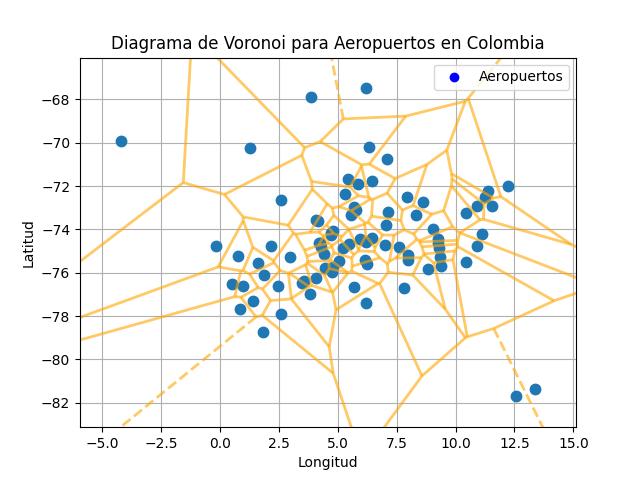

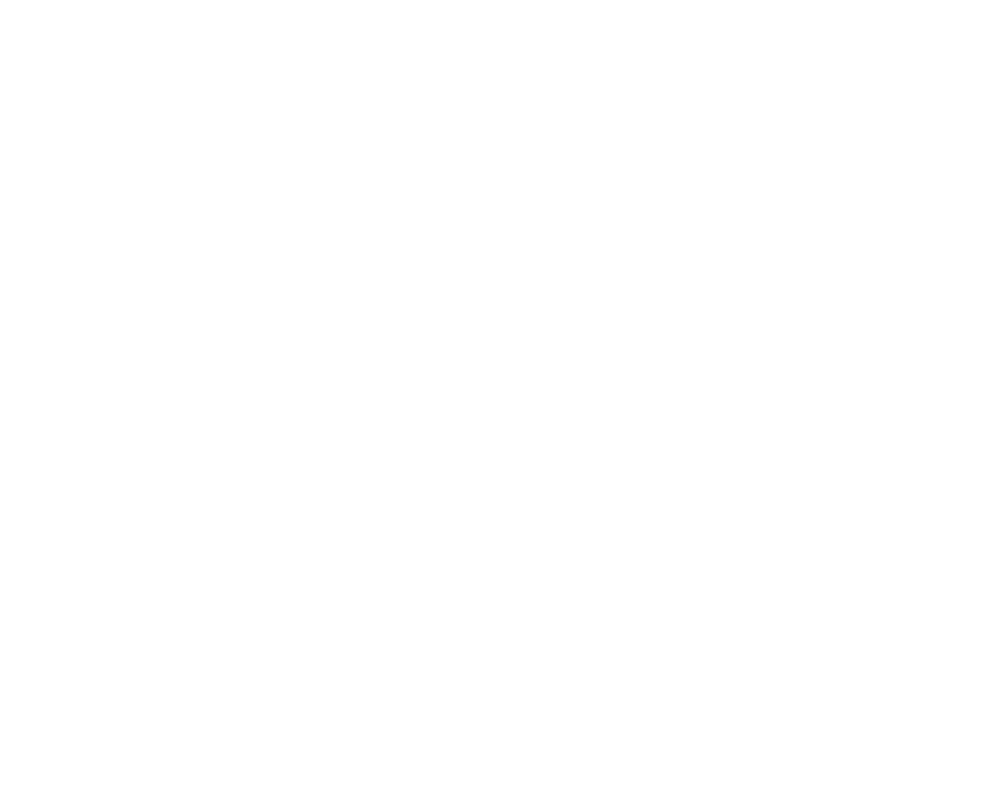

In [4]:
ruta = "airports_CO.csv"    

df = pd.read_csv(ruta)
lat_lot = df[['Latitud', 'Longitud']]
lat_lot_array = lat_lot.values
vor = calcular_voronoi(lat_lot)
graficar_voronoi(vor,lat_lot_array)

In [5]:
df

,Latitud,Longitud,Altitud,Ciudad,Departamento,Aeropuerto
0,4.244800,-74.649886,492.861639,Melgar,Tolima,Tolemaida Air Base
1,4.216442,-74.635047,313.334425,Melgar,Tolima,Melgar Ab Airport
2,7.927567,-72.511547,334.060826,Cucuta,NorteDeSantander,Camilo Daza Airport
3,4.701594,-74.146947,2548.432820,Bogota,DistritoCapital,Eldorado International Airport
4,5.432780,-71.662500,197.815200,Trinidad,Casanare,Trinidad Airport
...,...,...,...,...,...,...
76,7.126500,-73.184778,1187.805694,Bucaramanga,Santander,Palonegro
77,9.045542,-73.974931,33.832803,ElBanco,Magdalena,Las Flores
78,0.505228,-76.500836,248.412020,PuertoAsis,Putumayo,Tres de Mayo
79,4.452775,-75.766447,1216.152096,Armenia,Quindio,El Eden


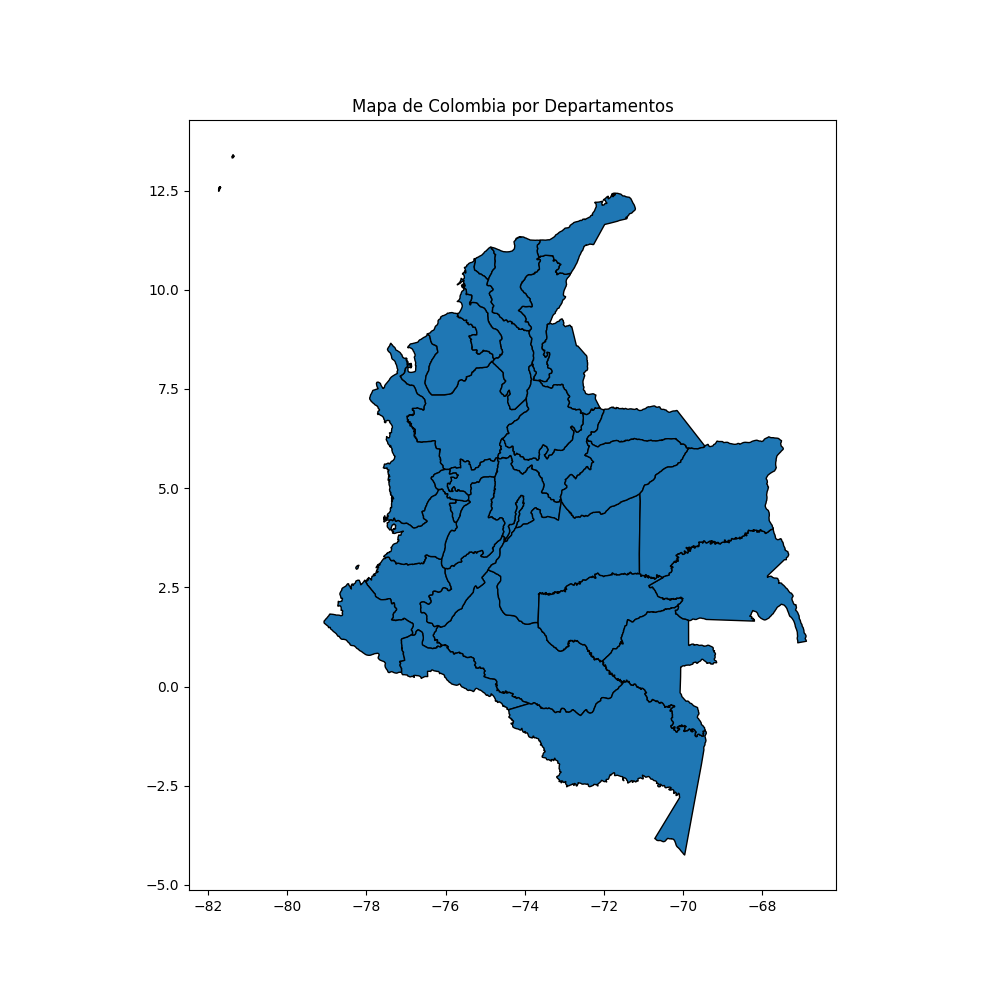

In [6]:


# Cargar el GeoJSON mapa de Colombia
mapa_colombia = gpd.read_file("colombia.geo.json")

# Visualizar el mapa base
mapa_colombia.plot(figsize=(10, 10), edgecolor='black')
plt.title("Mapa de Colombia por Departamentos")
plt.show()


##### EXplicación de los atributos utilizados para el calculo del diagrama

- `vor`: objeto generado con `scipy.spatial.Voronoi` que contiene toda la estructura del diagrama (vértices, regiones, etc.).
- `ax=ax`: se especifica el objeto `matplotlib` donde se dibujará el diagrama, en este caso el mismo que se usó para el mapa base.
- `show_vertices=False`: evita que se dibujen explícitamente los vértices del diagrama (los puntos donde se cruzan las aristas). Esto ayuda a que la gráfica se vea más limpia.
- `line_colors='orange'`: cambia el color de las aristas del diagrama de Voronoi a naranja para que se distingan sobre el mapa.
- `line_width=1.5`: ajusta el grosor de las líneas del diagrama para una mejor visibilidad.
- `line_alpha=0.7`: establece una transparencia (alfa) de 70% para las líneas, permitiendo que el mapa base se vea parcialmente a través de ellas.
- `point_size=10`: define el tamaño con el que se muestran los puntos (aeropuertos). En este caso se hace lo suficientemente grande para que se destaquen.

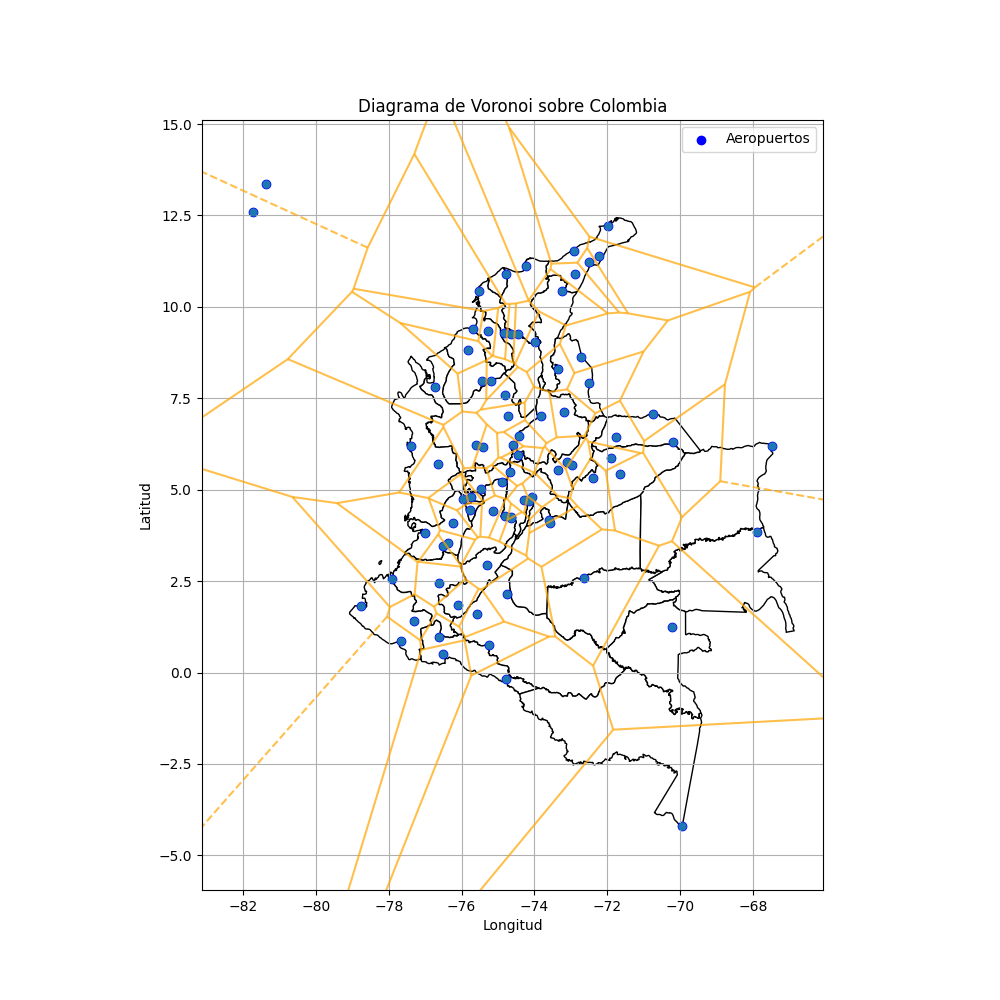

In [7]:
#mapa_colombia = gpd.read_file("colombia.geo.json")  # Ajusta si tu ruta es diferente


df = pd.read_csv("airports_CO.csv")

coordenadas = df[['Longitud', 'Latitud']].values  # Asegura el orden correcto: (lon, lat)

# === Calcular diagrama de Voronoi ===
vor = Voronoi(coordenadas)

# === Graficar ===
fig, ax = plt.subplots(figsize=(10, 10))

# Mapa base
mapa_colombia.plot(ax=ax, color='white', edgecolor='black')

# Voronoi
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='orange', line_width=1.5, line_alpha=0.7, point_size=10)

# Puntos de aeropuertos
ax.scatter(coordenadas[:, 0], coordenadas[:, 1], color='blue', label='Aeropuertos')

# Estética
ax.set_title("Diagrama de Voronoi sobre Colombia")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
plt.grid(True)
plt.show()

**Comentario final sobre el diagrama de Voronoi**

Se logró superponer correctamente el diagrama de Voronoi sobre el mapa de Colombia, generando una visualización clara del territorio dividido según la influencia de cada aeropuerto. Cada región representa el área geográfica más cercana a un aeropuerto determinado, permitiendo identificar su zona de cobertura teórica en casos de emergencia aérea.

Una observación interesante es que algunos aeropuertos, posiblemente de menor tamaño o relevancia operativa, generan celdas muy pequeñas o poco significativas en el diagrama. 

Como posible extensión para trabajos futuros, sería valioso:
- Clasificar los aeropuertos por capacidad (tráfico, infraestructura, categoría).
- Agrupar los secundarios a los más cercanos de mayor categoría.
- Generar un **diagrama de Voronoi ponderado**, en el que las regiones crezcan o decrezcan en función de la capacidad de cada aeropuerto, ofreciendo una representación más fiel de la cobertura real del sistema aeroportuario colombiano.


## Punto 2 
 Consider the curve
 α(t) = (acos(t),bsin(t),0) with 0 < t < 2π

In [8]:

# Definir símbolos
t = sp.symbols('t', real=True)
a, b = sp.symbols('a b', positive=True)

# Definir curva α(t)
alpha = sp.Matrix([a * sp.cos(t), b * sp.sin(t), 0])
alpha


Matrix([
[a*cos(t)],
[b*sin(t)],
[       0]])

In [9]:
# Derivadas
alpha_prime = sp.diff(alpha, t)
alpha_double_prime = sp.diff(alpha_prime, t)

# Mostrar resultados
display(alpha_prime) 
display(alpha_double_prime)



Matrix([
[-a*sin(t)],
[ b*cos(t)],
[        0]])

Matrix([
[-a*cos(t)],
[-b*sin(t)],
[        0]])

#### Evaluate curvature κ(t) for α(t)


In [10]:

# Producto cruzado y normas
cross = alpha_prime.cross(alpha_double_prime)
norm_cross = cross.norm()
norm_alpha_prime = alpha_prime.norm()

# Curvatura
kappa = norm_cross / norm_alpha_prime**3
display(sp.simplify(kappa))


a*b/(a**2*sin(t)**2 + b**2*cos(t)**2)**(3/2)

In [11]:
#Calcular vector normal unitario 𝑁⃗(𝑡)

# Vector tangente unitario
T = alpha_prime / norm_alpha_prime

# Derivada del vector tangente
T_prime = sp.diff(T, t)

# Norma de T'
norm_T_prime = T_prime.norm()

# Vector normal unitario
N = T_prime / norm_T_prime
display(sp.simplify(N))

Matrix([
[-b*sqrt(a**2*sin(t)**2 + b**2*cos(t)**2)*cos(t)/Abs(a**2*sin(t)**2 - b**2*sin(t)**2 + b**2)],
[-a*sqrt(a**2*sin(t)**2 + b**2*cos(t)**2)*sin(t)/Abs(a**2*sin(t)**2 - b**2*sin(t)**2 + b**2)],
[                                                                                          0]])

#### Obtain the evolute for the curve α(t)


In [12]:

beta = alpha + (1 / kappa) * N
display(sp.simplify(beta))
#beta


Matrix([
[ (a**2 - b**2)*cos(t)**3/a],
[(-a**2 + b**2)*sin(t)**3/b],
[                         0]])

#### Plot the curves α(t) and β(t) in the same frame. Set values a = 2 and b = 3 for the plot

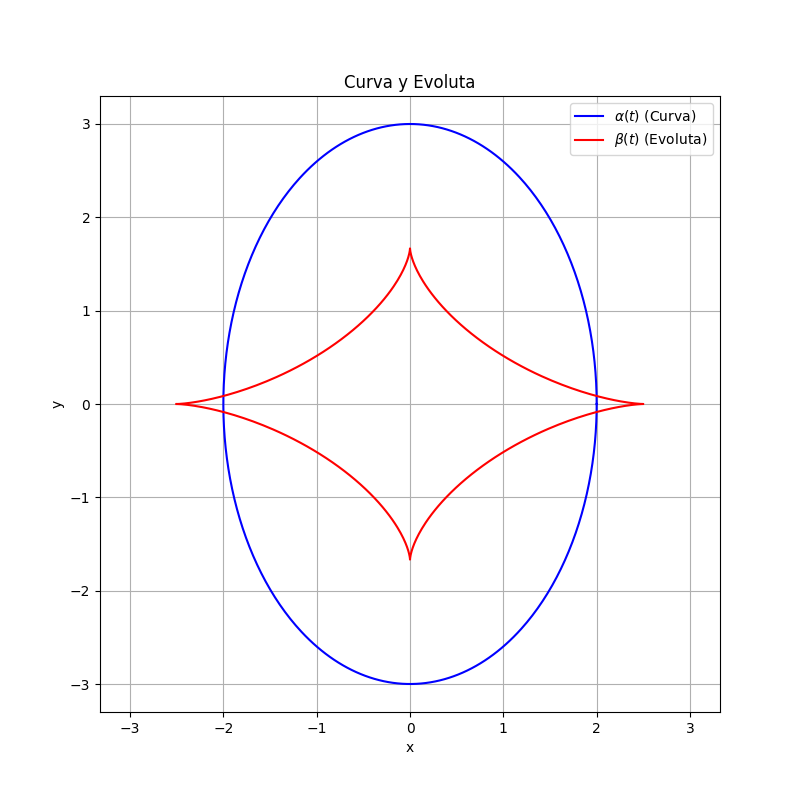

In [13]:
a_val , b_val = 2,3

# Sustituimos a y b
alpha_eval = alpha.subs({a: a_val, b: b_val})
beta_eval = beta.subs({a: a_val, b: b_val})

# Creamos funciones lambdify de cada componente
alpha_x = sp.lambdify(t, alpha_eval[0], 'numpy')
alpha_y = sp.lambdify(t, alpha_eval[1], 'numpy')
beta_x = sp.lambdify(t, beta_eval[0], 'numpy')
beta_y = sp.lambdify(t, beta_eval[1], 'numpy')

# Evaluamos
t_vals = np.linspace(0, 2*np.pi, 500)
x_alpha = alpha_x(t_vals)
y_alpha = alpha_y(t_vals)
x_beta = beta_x(t_vals)
y_beta = beta_y(t_vals)

# Graficamos
plt.figure(figsize=(8, 8))
plt.plot(x_alpha, y_alpha, label=r'$\alpha(t)$ (Curva)', color='blue')
plt.plot(x_beta, y_beta, label=r'$\beta(t)$ (Evoluta)', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curva y Evoluta')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


**Comentario final sobre la evoluta**

Al observar la gráfica, es interesante ver cómo la evoluta $( \beta(t) )$ nos revela algo que no es tan evidente en la elipse original $(\alpha(t) = (a\cos t,\ b\sin t))$.  
Las puntas de la evoluta aparecen justo en los extremos del eje mayor y menor, mostrando los lugares donde la curvatura cambia más rápido.  
Es curioso cómo, a pesar de que la elipse es una curva suave, su evoluta tiene estas formas puntiagudas (cúspides), lo cual dice mucho sobre cómo varía la curvatura en el recorrido, observar **dónde se concentra o se dispersa la curvatura** a lo largo de una curva. Nos deja ver —literalmente— cómo la geometría interna se despliega a partir de la forma externa.


### Punto 3 


####  Consider the curve 

$$α(t) = (cos(3t)cos(t),cos(3t)sin(t),0)        $$
$$0 ≤ t ≤ 2π$$

Plot the curve α(t) with the tangent vector when t = 0.

In [14]:
# Variables simbólicas
t = sp.symbols('t', real=True)
alpha = sp.Matrix([
    sp.cos(3*t) * sp.cos(t),
    sp.cos(3*t) * sp.sin(t),
    0
])

display(alpha)

Matrix([
[cos(t)*cos(3*t)],
[sin(t)*cos(3*t)],
[              0]])

In [15]:

# Derivada simbólica (vector tangente)
alpha_prime = sp.diff(alpha, t)
display(alpha_prime)

Matrix([
[-sin(t)*cos(3*t) - 3*sin(3*t)*cos(t)],
[-3*sin(t)*sin(3*t) + cos(t)*cos(3*t)],
[                                   0]])

In [16]:

# Evaluar en t=0
alpha_0 = alpha.subs(t, 0)
alpha_prime_0 = alpha_prime.subs(t, 0)
display(alpha_prime_0)

Matrix([
[0],
[1],
[0]])

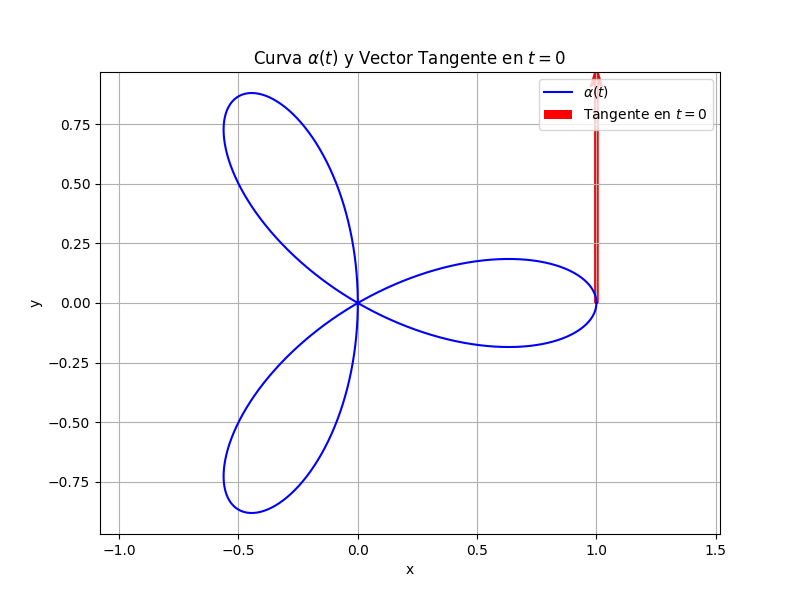

In [17]:
# Separar componentes
alpha_x_func = sp.lambdify(t, alpha[0], 'numpy')
alpha_y_func = sp.lambdify(t, alpha[1], 'numpy')

# Evaluar
t_vals = np.linspace(0, np.pi, 500)
x_vals = alpha_x_func(t_vals)
y_vals = alpha_y_func(t_vals)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label=r'$\alpha(t)$', color='blue')

# Vector tangente en t = 0
x0, y0 = float(alpha_0[0]), float(alpha_0[1])
dx, dy = float(alpha_prime_0[0]), float(alpha_prime_0[1])
plt.quiver(x0, y0, dx, dy, angles='xy', scale_units='xy', scale=1, color='red', label='Tangente en $t=0$')

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curva $\\alpha(t)$ y Vector Tangente en $t=0$')
plt.grid(True)
plt.legend()
plt.show()

Plot the curvature κ(t).

In [18]:
# Derivadas simbólicas
alpha_prime = sp.diff(alpha, t)
alpha_double_prime = sp.diff(alpha_prime, t)


# Producto cruzado y normas
cross = alpha_prime.cross(alpha_double_prime)
norm_cross = cross.norm()
norm_alpha_prime = alpha_prime.norm()

display("α'(t)=",alpha_prime)
display("α''(t)=",alpha_double_prime)
display("α'X α''=",cross)
display("||α'X α''||=",norm_cross)
display("||α'||)=",norm_alpha_prime)


"α'(t)="

Matrix([
[-sin(t)*cos(3*t) - 3*sin(3*t)*cos(t)],
[-3*sin(t)*sin(3*t) + cos(t)*cos(3*t)],
[                                   0]])

"α''(t)="

Matrix([
[ 6*sin(t)*sin(3*t) - 10*cos(t)*cos(3*t)],
[-10*sin(t)*cos(3*t) - 6*sin(3*t)*cos(t)],
[                                      0]])

"α'X α''="

Matrix([
[                                                                                                                                                                  0],
[                                                                                                                                                                  0],
[-(-3*sin(t)*sin(3*t) + cos(t)*cos(3*t))*(6*sin(t)*sin(3*t) - 10*cos(t)*cos(3*t)) + (-10*sin(t)*cos(3*t) - 6*sin(3*t)*cos(t))*(-sin(t)*cos(3*t) - 3*sin(3*t)*cos(t))]])

"||α'X α''||="

Abs(-(-3*sin(t)*sin(3*t) + cos(t)*cos(3*t))*(6*sin(t)*sin(3*t) - 10*cos(t)*cos(3*t)) + (-10*sin(t)*cos(3*t) - 6*sin(3*t)*cos(t))*(-sin(t)*cos(3*t) - 3*sin(3*t)*cos(t)))

"||α'||)="

sqrt((3*sin(t)*sin(3*t) - cos(t)*cos(3*t))**2 + (sin(t)*cos(3*t) + 3*sin(3*t)*cos(t))**2)

In [19]:
#curvatura
kappa = norm_cross / norm_alpha_prime**3
display(sp.simplify(kappa))

2*(7 - 2*cos(6*t))/(128*sin(t)**6 - 192*sin(t)**4 + 72*sin(t)**2 + 1)**(3/2)

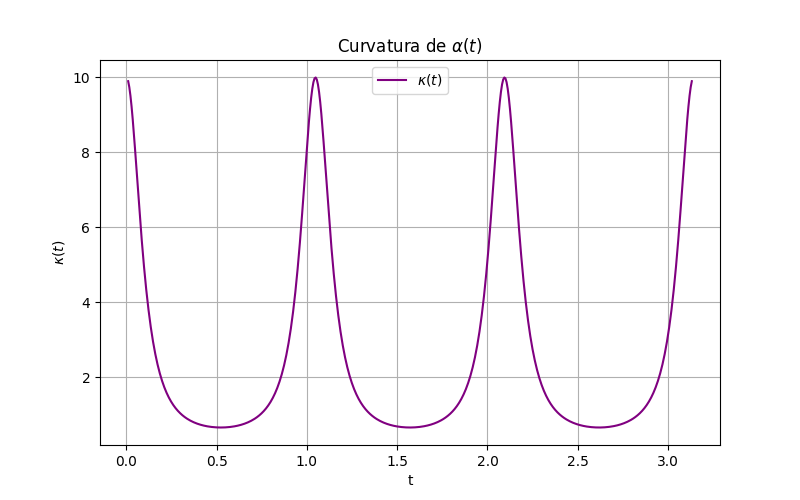

In [20]:

# Variable y función evaluable

kappa_func = sp.lambdify(t, kappa, 'numpy')

# Evaluar en un rango
t_vals = np.linspace(0.01, np.pi - 0.01, 500)  # evitar bordes
kappa_vals = kappa_func(t_vals)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(t_vals, kappa_vals, color='purple', label=r'$\kappa(t)$')
plt.title('Curvatura de $\\alpha(t)$')
plt.xlabel('t')
plt.ylabel(r'$\kappa(t)$')
plt.grid(True)
plt.legend()
plt.show()

**Comentario sobre la curvatura de  $\alpha(t) $**

En esta gráfica podemos ver cómo varía la curvatura de la curva $( \alpha(t) )$ a lo largo del intervalo. Los picos hacia arriba corresponden a los puntos donde los pétalos de la curva se intersectan en el centro: ahí es donde se concentra la mayor curvatura.

En cambio, las zonas más planas, que se ven como parábolas suaves entre los picos, representan los pétalos. Esto muestra que los pétalos no tienen cambios bruscos de dirección —su curvatura es suave y más uniforme—, mientras que en el centro, donde la trayectoria cambia repentinamente, la curvatura se dispara.



### Evaluate the curve’s length


**Cálculo de la longitud de la curva**

La longitud se define como:  
$( L = \int_a^b \|\alpha'(t)\|\, dt )$

En este caso, la integral de la norma del vector velocidad no puede resolverse simbólicamente. Por tanto, se emplean dos métodos numéricos:

- **Suma de Riemann:** evalúa $\|\alpha'(t)\|$ en muchos puntos del intervalo y aproxima el área como suma de rectángulos. Es fácil de implementar, pero no controla el error numérico.

- **Cuadratura adaptativa Gauss–Kronrod (`scipy.integrate.quad`):**  
  Este método combina reglas de cuadratura de Gauss con nodos adicionales (Kronrod) para estimar el valor de la integral y su error. Es altamente eficiente porque ajusta el tamaño de los subintervalos automáticamente según la variación de la función, logrando alta precisión con menos evaluaciones. El error estimado suele ser menor a $10^{-7}$, lo que brinda resultados confiables incluso en funciones con cambios rápidos.

Este algoritmo está implementado en SciPy a través de la función `quad`, basada en el integrador de QUADPACK, una biblioteca numérica ampliamente utilizada para integración en una dimensión.

**Referencia:**  
Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17, 261–272.  
https://doi.org/10.1038/s41592-019-0686-2


In [21]:
# Calcular norma de α'(t)
alpha_prime = sp.diff(alpha, t)
norm_alpha_prime = alpha_prime.norm()

# Intentar integración simbólica
L_exacta = sp.integrate(norm_alpha_prime, (t, 0, sp.pi))
display(L_exacta)

# Verificar si fue evaluada o no
if isinstance(L_exacta, sp.Integral):
    print("⚠️ No se pudo evaluar simbólicamente. Usamos método numérico.")
    
    # Crear función numérica
    norm_func = sp.lambdify(t, norm_alpha_prime, 'numpy')
    t_vals = np.linspace(0, np.pi, 1000)
    dt = t_vals[1] - t_vals[0]
    L_numerica = np.sum(norm_func(t_vals)) * dt
    longitud, error = quad(norm_func, 0, np.pi)
    print(f"Longitud (quad CALCULADO Con Gauss–Kronrod): {longitud:.8f}, error estimado: {error:.2e}")
    print(f"📏 Longitud (numérica CALCULADA A TRAVES DE RIEMAN): {L_numerica:.6f}")
else:
    print("✅ Longitud evaluada simbólicamente:")
    sp.pprint(L_exacta)
    print(f"📏 Longitud (exacta): {float(L_exacta):.6f}")


Integral(sqrt(sin(t)**2 + cos(t)**2)*sqrt(9*sin(3*t)**2 + cos(3*t)**2), (t, 0, pi))

⚠️ No se pudo evaluar simbólicamente. Usamos método numérico.
Longitud (quad CALCULADO Con Gauss–Kronrod): 6.68244661, error estimado: 9.63e-08
📏 Longitud (numérica CALCULADA A TRAVES DE RIEMAN): 6.685591


Al comparar ambos métodos numéricos, observamos que la longitud obtenida por la suma de Riemann es 6.685591, mientras que el valor calculado mediante `quad` (Gauss–Kronrod) es 6.68244661, con un error estimado de $9.63 \times 10^{-8}$.

La diferencia entre ambos métodos es de aproximadamente **0.0031**, lo cual puede atribuirse a que la suma de Riemann no adapta el tamaño del paso ni controla el error acumulado.

Dado que `quad` ofrece un estimado de error muy bajo y utiliza un esquema adaptativo más robusto, **usaremos su resultado como la longitud más confiable de la curva**.


### Evaluate the rotation index.

In [22]:
# Función simbólica del integrando
integrando = sp.simplify(kappa * norm_alpha_prime)

# Función numérica
integrando_func = sp.lambdify(t, integrando, 'numpy')

# Integración con Gauss–Kronrod
rotacion_total, error_rot = quad(integrando_func, 0, np.pi)

# Índice de rotación
I = rotacion_total / (2 * np.pi)

print(f"🎯 Índice de rotación: {I:.6f}")
print(f"🧮 Error estimado en integración: {error_rot:.2e}")


🎯 Índice de rotación: 2.000000
🧮 Error estimado en integración: 1.75e-07


#### Gráfcos adicinales interesantes

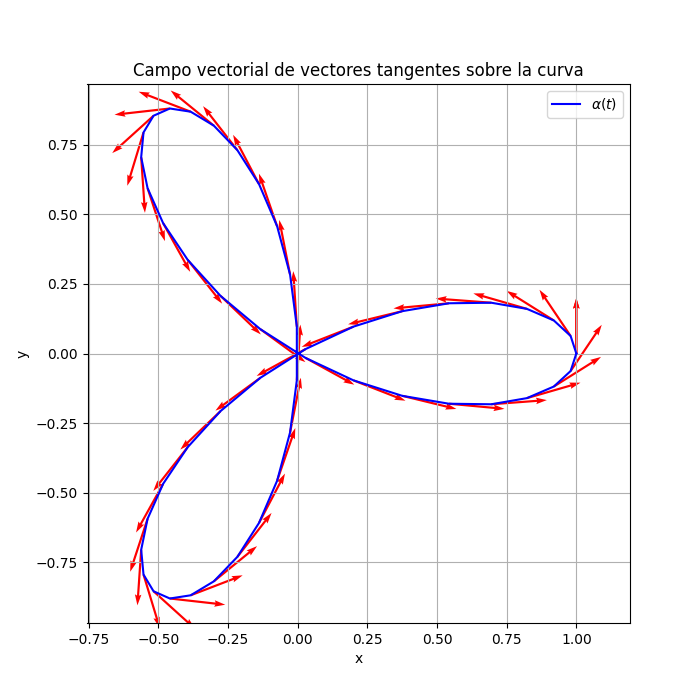

In [23]:

# Definición simbólica de la curva y su derivada
t_sym = sp.symbols('t', real=True)
alpha = sp.Matrix([
    sp.cos(3*t_sym) * sp.cos(t_sym),
    sp.cos(3*t_sym) * sp.sin(t_sym)
])
alpha_prime = sp.diff(alpha, t_sym)

# Conversión a funciones numéricas
alpha_func = sp.lambdify(t_sym, alpha, 'numpy')
alpha_prime_func = sp.lambdify(t_sym, alpha_prime, 'numpy')

# Dominio de evaluación
t_vals = np.linspace(0, np.pi, 50)

# Evaluación vectorizada y limpia
P = np.squeeze(np.array(alpha_func(t_vals)))       # shape (2, n)
V = np.squeeze(np.array(alpha_prime_func(t_vals))) # shape (2, n)

# Normalizar vectores tangentes
V_unit = V / np.linalg.norm(V, axis=0) * 0.2

# Coordenadas para quiver
X, Y = P[0], P[1]
U, W = V_unit[0], V_unit[1]

# --- Gráfica ---
plt.figure(figsize=(7, 7))
plt.plot(X, Y, 'b-', label=r'$\alpha(t)$')
plt.quiver(X, Y, U, W, color='red', angles='xy', scale_units='xy', scale=1, width=0.004)

plt.axis('equal')
plt.grid(True)
plt.title('Campo vectorial de vectores tangentes sobre la curva')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
C:\Users\juanh\AppData\Local\Temp\ipykernel_16960\3901748404.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Campo de normales unitarios en $\mathbb{R}^2$ (visualización ajustada)')


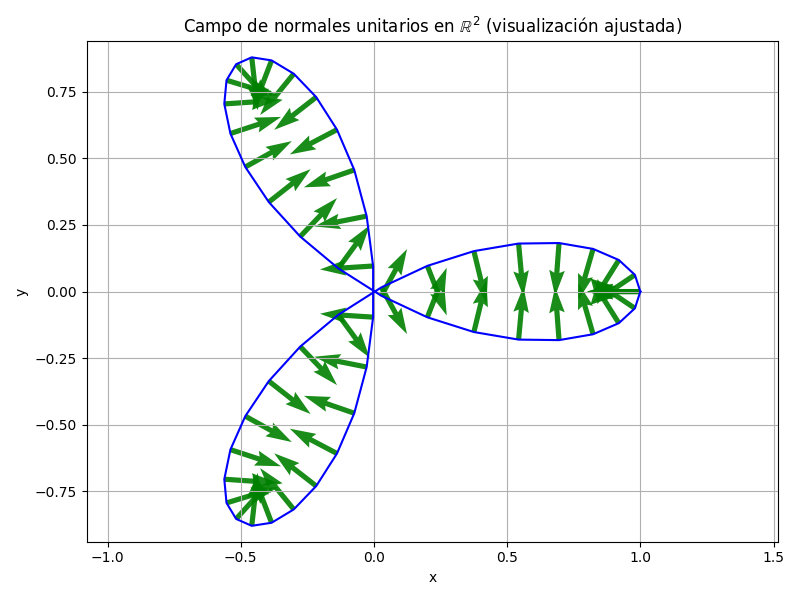

In [24]:

# === Definir curva y vectores ===
t = sp.symbols('t', real=True)
alpha = sp.Matrix([
    sp.cos(3*t) * sp.cos(t),
    sp.cos(3*t) * sp.sin(t),
    0
])
alpha_prime = sp.diff(alpha, t)
T = alpha_prime / alpha_prime.norm()
T_prime = sp.diff(T, t)
N_raw = T_prime
N_norm = sp.sqrt(N_raw.dot(N_raw))
N_sym = N_raw / N_norm  # normalización simbólica

# === Lambdify coordenadas (2D) ===
alpha_x = sp.lambdify(t, alpha[0], 'numpy')
alpha_y = sp.lambdify(t, alpha[1], 'numpy')
N_x_raw = sp.lambdify(t, N_sym[0], 'numpy')
N_y_raw = sp.lambdify(t, N_sym[1], 'numpy')

# === Evaluar ===
t_vals = np.linspace(0, np.pi, 50)

P = np.vstack([
    alpha_x(t_vals),
    alpha_y(t_vals)
])

# Evaluar y normalizar manualmente
V_raw = np.vstack([
    N_x_raw(t_vals),
    N_y_raw(t_vals)
])
norms = np.linalg.norm(V_raw, axis=0)
V = V_raw / norms  # Normalización numérica final

# Reducir escala para visualización (sin alterar dirección ni unidad)
V_scaled = V * 0.2

# === Graficar ===
fig, ax = plt.subplots(figsize=(8, 6))

# Curva
ax.plot(P[0], P[1], color='blue')

# Vectores normales
for i in range(len(t_vals)):
    x, y = P[:, i]
    dx, dy = V_scaled[:, i]
    ax.quiver(x, y, dx, dy, color='green', angles='xy', scale_units='xy', scale=1, alpha=0.9)

# Estética
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Campo de normales unitarios en $\mathbb{R}^2$ (visualización ajustada)')
ax.axis('equal')
ax.grid(True)
plt.tight_layout()
plt.show()


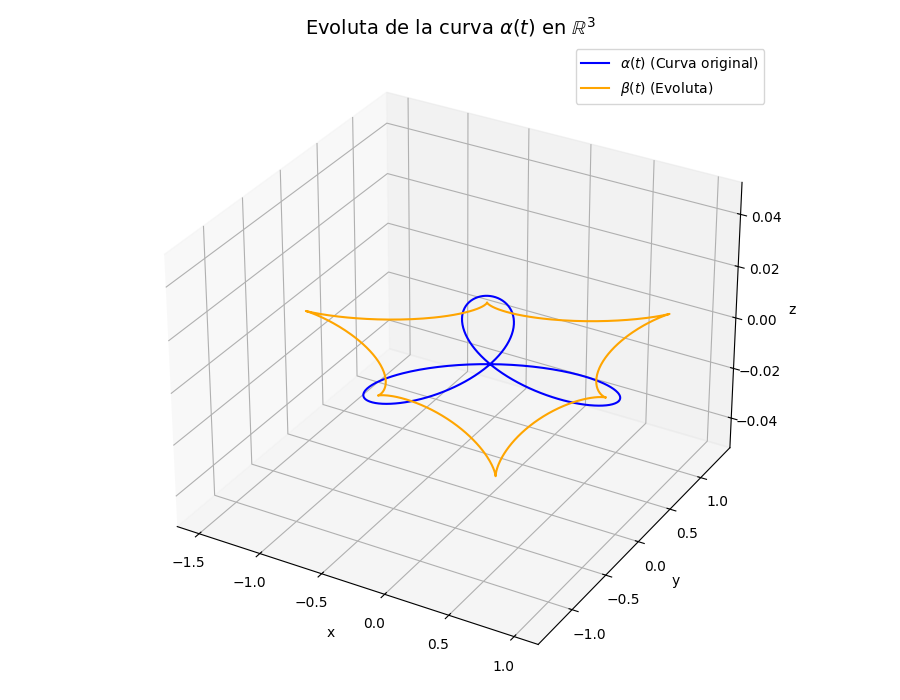

In [25]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Paso 1: Definición simbólica ===
t = sp.symbols('t', real=True)

# Curva original
alpha = sp.Matrix([
    sp.cos(3*t) * sp.cos(t),
    sp.cos(3*t) * sp.sin(t),
    0
])

# Derivadas
alpha_prime = sp.diff(alpha, t)
alpha_double_prime = sp.diff(alpha_prime, t)

# === Paso 2: Curvatura κ(t) ===
cross = alpha_prime.cross(alpha_double_prime)
kappa = cross.norm() / alpha_prime.norm()**3

# === Paso 3: Vector normal unitario N(t) ===
T = alpha_prime / alpha_prime.norm()
T_prime = sp.diff(T, t)
N = T_prime / T_prime.norm()

# === Paso 4: Evoluta β(t) ===
beta = alpha + (1 / kappa) * N

# === Paso 5: lambdify por componente (robusto) ===
alpha_x = sp.lambdify(t, alpha[0], 'numpy')
alpha_y = sp.lambdify(t, alpha[1], 'numpy')
alpha_z = sp.lambdify(t, alpha[2], 'numpy')  # Esto es simplemente 0

beta_x = sp.lambdify(t, beta[0], 'numpy')
beta_y = sp.lambdify(t, beta[1], 'numpy')
beta_z = sp.lambdify(t, beta[2], 'numpy')

# === Paso 6: Evaluación ===
t_vals = np.linspace(0.01, np.pi - 0.01, 500)  # evitamos bordes peligrosos

alpha_vals = np.vstack([
    alpha_x(t_vals),
    alpha_y(t_vals),
    np.zeros_like(t_vals)  # alpha_z(t) = 0
])

beta_vals = np.vstack([
    beta_x(t_vals),
    beta_y(t_vals),
    np.zeros_like(t_vals)  # curva evoluta también vive en z=0
])


# === Paso 7: Graficar ===
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Curva original
ax.plot(alpha_vals[0], alpha_vals[1], alpha_vals[2], color='blue', label=r'$\alpha(t)$ (Curva original)')

# Evoluta
ax.plot(beta_vals[0], beta_vals[1], beta_vals[2], color='orange', label=r'$\beta(t)$ (Evoluta)')

# Estética
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'Evoluta de la curva $\alpha(t)$ en $\mathbb{R}^3$', fontsize=14)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


Ver estas tres gráficas juntas me permitió entender mucho mejor la geometría de la curva. El campo tangente me muestra cómo avanza, las normales hacia dónde se curva, y la evoluta me deja ver claramente dónde la curvatura se concentra.


 ## PUNTO 4

 ### Consider the curve
$$( \alpha(t) = \left( \frac{\cos(t)}{1 + \sin^2(t)},\ \frac{\sin(t)\cos(t)}{1 + \sin^2(t)},\ 0 \right),\quad 0 < t < 2\pi )$$


#### Plot the curve α(t) with the tangent vector when t = 0.

In [26]:

# === Simbología ===
t = sp.symbols('t', real=True)
alpha = sp.Matrix([
    sp.cos(t) / (1 + sp.sin(t)**2),
    (sp.sin(t)*sp.cos(t)) / (1 + sp.sin(t)**2),
    0
])

alpha_prime = sp.diff(alpha, t)

display("α(t)=", alpha)
display("α'(t)=", alpha_prime)

'α(t)='

Matrix([
[       cos(t)/(sin(t)**2 + 1)],
[sin(t)*cos(t)/(sin(t)**2 + 1)],
[                            0]])

"α'(t)="

Matrix([
[                                  -sin(t)/(sin(t)**2 + 1) - 2*sin(t)*cos(t)**2/(sin(t)**2 + 1)**2],
[-sin(t)**2/(sin(t)**2 + 1) + cos(t)**2/(sin(t)**2 + 1) - 2*sin(t)**2*cos(t)**2/(sin(t)**2 + 1)**2],
[                                                                                                0]])

In [27]:
# ===evaluar  t = 0 ===
alpha_0 = alpha.subs(t, 0)
alpha_prime_0 = alpha_prime.subs(t, 0)

display(alpha_0)
display(alpha_prime_0)

Matrix([
[1],
[0],
[0]])

Matrix([
[0],
[1],
[0]])

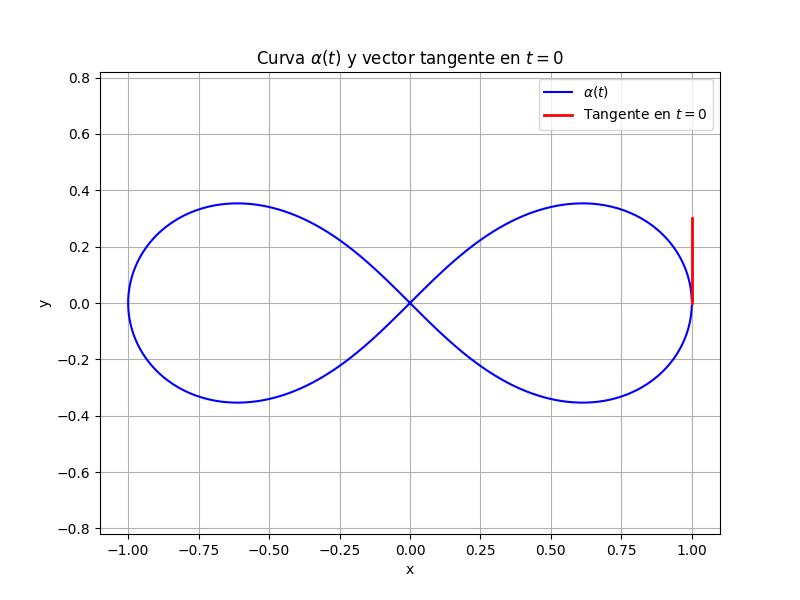

In [28]:
# === Lambdify para graficar ===
x_func = sp.lambdify(t, alpha[0], 'numpy')
y_func = sp.lambdify(t, alpha[1], 'numpy')

# === Evaluación y gráfico ===
t_vals = np.linspace(0.01, 2*np.pi - 0.01, 500)
x_vals = x_func(t_vals)
y_vals = y_func(t_vals)

# Vector tangente como línea
x0, y0 = float(alpha_0[0]), float(alpha_0[1])
dx, dy = float(alpha_prime_0[0]), float(alpha_prime_0[1])
scale = 0.3
x1, y1 = x0 + dx * scale, y0 + dy * scale

# === Graficar ===
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label=r'$\alpha(t)$', color='blue')
plt.plot([x0, x1], [y0, y1], color='red', linewidth=2, label='Tangente en $t=0$')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curva $\\alpha(t)$ y vector tangente en $t=0$')
plt.legend()
plt.show()


### Plot the curvature κ(t).

In [29]:
# === Derivadas ===
alpha_double_prime = sp.diff(alpha_prime, t)

# === Curvatura κ(t) ===
cross = alpha_prime.cross(alpha_double_prime)
kappa = cross.norm() / alpha_prime.norm()**3

# Simplificar por si acaso (opcional)
kappa_simplified = sp.simplify(kappa)

display("α''(t)=", alpha_double_prime)
display("κ(t)=", kappa_simplified)



"α''(t)="

Matrix([
[                -cos(t)/(sin(t)**2 + 1) + 6*sin(t)**2*cos(t)/(sin(t)**2 + 1)**2 - 2*cos(t)**3/(sin(t)**2 + 1)**2 + 8*sin(t)**2*cos(t)**3/(sin(t)**2 + 1)**3],
[-4*sin(t)*cos(t)/(sin(t)**2 + 1) + 6*sin(t)**3*cos(t)/(sin(t)**2 + 1)**2 - 6*sin(t)*cos(t)**3/(sin(t)**2 + 1)**2 + 8*sin(t)**3*cos(t)**3/(sin(t)**2 + 1)**3],
[                                                                                                                                                          0]])

'κ(t)='

3*Abs(cos(t))/sqrt(sin(t)**2 + 1)

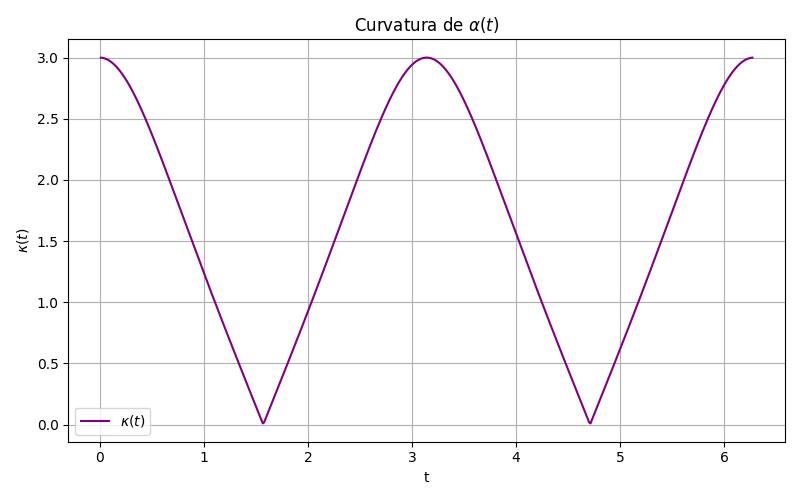

In [30]:
# Lambdify
kappa_func = sp.lambdify(t, kappa_simplified, 'numpy')

# Evaluar numéricamente
t_vals_kappa = np.linspace(0.01, 2*np.pi - 0.01, 500)
kappa_vals = kappa_func(t_vals_kappa)

# === Graficar curvatura ===
plt.figure(figsize=(8, 5))
plt.plot(t_vals_kappa, kappa_vals, color='purple', label=r'$\kappa(t)$')
plt.xlabel('t')
plt.ylabel(r'$\kappa(t)$')
plt.title('Curvatura de $\\alpha(t)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 🧠 Reflexión sobre la curvatura en esta curva

Lo que veo con esta curva es que al tener **una sola intersección**, todo el "giro" o el cambio brusco de dirección se **concentra justo en ese punto**. Y eso se nota clarísimo en la gráfica de la curvatura: se dispara fuerte, como un pico puntiagudo.

Curvas más simétricas o con varias intersecciones (como la flor de 3 pétalos) reparten esos giros, así que la curvatura **se suaviza**: los cambios siguen estando ahí, pero no tan concentrados. En cambio, acá toda la energía del cambio de dirección **revienta en el centro**.

Es como si el vector tangente no tuviera más opción que girar bruscamente solo una vez, y eso hace que el pico de curvatura sea más agresivo.

> Curvas con muchas intersecciones = distribuyen la torsión  
> Curvas con una sola intersección = concentran la torsión



### Evaluate the curve’s length

In [31]:
#se demora un poco en ejecutarse 30 seg aprox
# === Norm ||α'(t)|| ===
norm_alpha_prime = alpha_prime.norm()

# === Intentar integrar simbólicamente ===
L_expr = sp.integrate(norm_alpha_prime, (t, 0, 2*sp.pi))

try:
   # Evaluar la integral simbólicamente (como expresión)
    L_expr = sp.integrate(norm_alpha_prime, (t, 0, 2*sp.pi))

    print("📐 Longitud simbólica (expresión):")
    sp.pprint(L_expr)  # o print(L_expr)

    # Evaluar su valor decimal
    L_exacta = L_expr.evalf()
    print("\n✅ Longitud (valor numérico):", float(L_exacta))

except:
    # === Si falla, usar integración numérica ===
    norm_func = sp.lambdify(t, norm_alpha_prime, 'numpy')
    L_numerica, error = quad(norm_func, 0, 2*np.pi)
    print("⚠️ No se pudo evaluar simbólicamente. Usamos método numérico.")
    print(f"📏 Longitud (quad): {L_numerica:.8f}, error estimado: {error:.2e}")

📐 Longitud simbólica (expresión):
2⋅π                                                        
 ⌠                                                         
 ⎮     _________________________________________________   
 ⎮    ╱    4           2       2         2         4       
 ⎮  ╲╱  sin (t) + 2⋅sin (t)⋅cos (t) + sin (t) + cos (t)    
 ⎮  ──────────────────────────────────────────────────── dt
 ⎮                         2                               
 ⎮                      sin (t) + 1                        
 ⌡                                                         
 0                                                         

✅ Longitud (valor numérico): 5.244115108584239


### Evaluate the rotation index. Use numerical integration if necessary. Interpret your  result.

In [32]:
################################################################################
#Por favor detener el bloque si no se detiene en 5 seg, el algoritmo esta convergiendo pero no detine ejecución.
#Tal parece que es culpa de unas configuraciones de jupyter dentro de visual
################################################################################
# === Elemento diferencial para el índice ===
integrando = kappa * norm_alpha_prime

# === Intentar resolverlo simbólicamente ===
try:
    rot_expr = sp.integrate(integrando, (t, 0, 2*sp.pi))
    I = (1 / (2 * sp.pi)) * rot_expr.evalf()
    print("✅ Índice de rotación:", float(I))
except:
    # Si falla simbólicamente → usar integración numérica
    integrando_func = sp.lambdify(t, integrando, 'numpy')
    integral_num, error = quad(integrando_func, 0, 2*np.pi, epsabs=1e-2, epsrel=1e-2,limit =10)

    I = integral_num / (2 * np.pi)
    print("⚠️ Integración simbólica fallida. Usamos método numérico.")
    print(f"🎯 Índice de rotación (numérico): {I:.6f}")
    print(f"🧮 Error estimado: {error:.2e}")


⚠️ Integración simbólica fallida. Usamos método numérico.
🎯 Índice de rotación (numérico): 1.500000
🧮 Error estimado: 2.14e-10


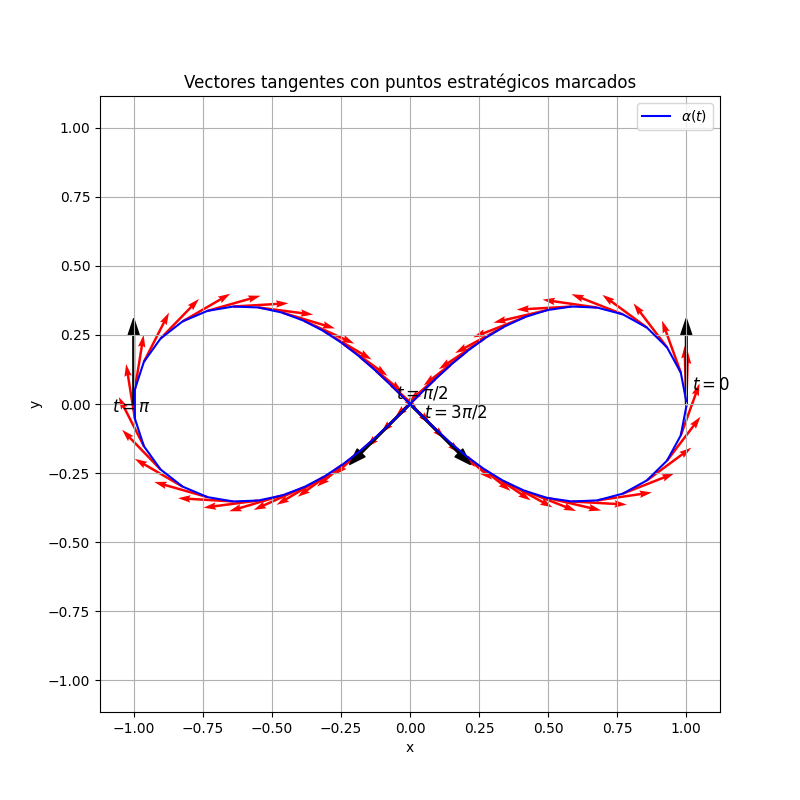

In [33]:

# === Definición simbólica ===
t = sp.symbols('t', real=True)
alpha = sp.Matrix([
    sp.cos(t) / (1 + sp.sin(t)**2),
    (sp.sin(t)*sp.cos(t)) / (1 + sp.sin(t)**2),
    0
])
alpha_prime = sp.diff(alpha, t)
alpha_double_prime = sp.diff(alpha_prime, t)

# === Cálculo de curvatura ===
cross = alpha_prime.cross(alpha_double_prime)
kappa = cross.norm() / alpha_prime.norm()**3
norm_alpha_prime = alpha_prime.norm()



# === Visualización del campo tangente ===
# Funciones numéricas
alpha_func = sp.lambdify(t, alpha[:2], 'numpy')
alpha_prime_func = sp.lambdify(t, alpha_prime[:2], 'numpy')

# Dominio
t_vals = np.linspace(0.01, 2*np.pi - 0.01, 60)
P = np.array(alpha_func(t_vals))
V = np.array(alpha_prime_func(t_vals))

# Normalización
V_unit = V / np.linalg.norm(V, axis=0) * 0.2

# Coordenadas
X, Y = P[0], P[1]
U, W = V_unit[0], V_unit[1]
# --- Punto clave: mostrar t estratégicos en los vectores tangentes ---
# Escoger puntos t específicos donde se vea bien el cambio de orientación
t_estrategicos = [0, np.pi/2, np.pi, 3*np.pi/2]
t_labels = [r'$t=0$', r'$t=\pi/2$', r'$t=\pi$', r'$t=3\pi/2$']

# Evaluar puntos y vectores tangentes
P_marked = np.array(alpha_func(t_estrategicos))
V_marked = np.array(alpha_prime_func(t_estrategicos))
V_marked_unit = V_marked / np.linalg.norm(V_marked, axis=0) * 0.25


# === Gráfica con etiquetas ===
plt.figure(figsize=(8, 8))
plt.plot(X, Y, 'b-', label=r'$\alpha(t)$')
plt.quiver(X, Y, U, W, color='red', angles='xy', scale_units='xy', scale=1, width=0.004)

# Añadir vectores marcados y etiquetas desplazadas para evitar solapamientos
offsets = [(0.02, 0.05), (-0.05, 0.02), (-0.08, -0.03), (0.05, -0.05), (0.02, 0.06)]

for i, label in enumerate(t_labels):
    x, y = P_marked[0, i], P_marked[1, i]
    u, v = V_marked_unit[0, i], V_marked_unit[1, i]

    # Flecha del vector destacado
    plt.arrow(x, y, u, v, color='black', width=0.006, head_width=0.04)

    # Etiqueta desplazada
    dx, dy = offsets[i]
    plt.text(x + dx, y + dy, label, fontsize=12, color='black', weight='bold')


plt.axis('equal')
plt.grid(True)
plt.title('Vectores tangentes con puntos estratégicos marcados')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


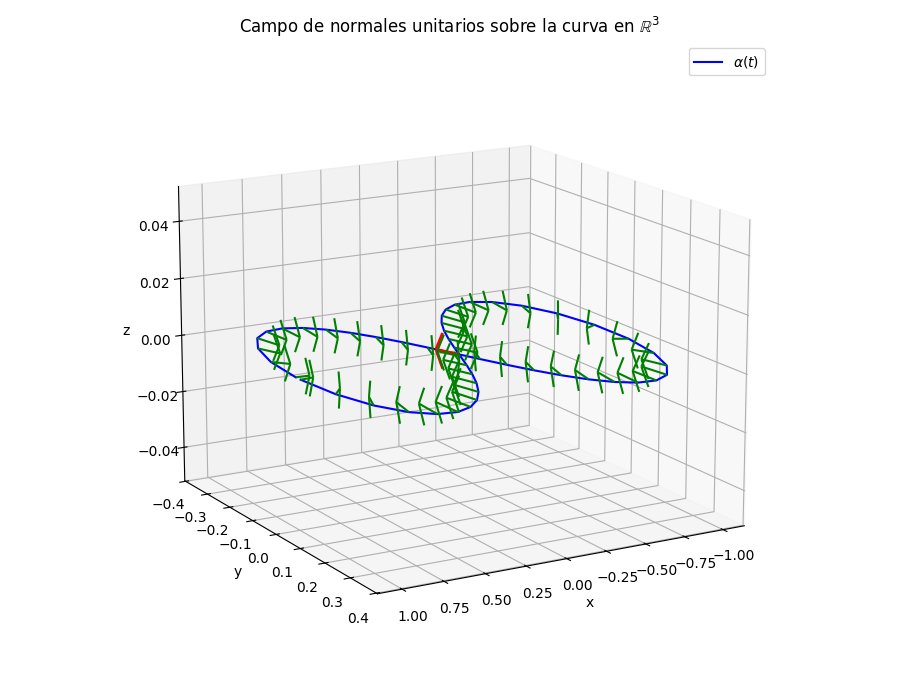

In [34]:

# === Cálculo de vectores normales ===
alpha_prime = sp.diff(alpha, t)
T = alpha_prime / alpha_prime.norm()
T_prime = sp.diff(T, t)
N = T_prime / T_prime.norm()

# === Lambdify por componente ===
alpha_x = sp.lambdify(t, alpha[0], 'numpy')
alpha_y = sp.lambdify(t, alpha[1], 'numpy')
alpha_z = sp.lambdify(t, alpha[2], 'numpy')

N_x = sp.lambdify(t, N[0], 'numpy')
N_y = sp.lambdify(t, N[1], 'numpy')
N_z = sp.lambdify(t, N[2], 'numpy')

# === Evaluación ===
t_vals = np.linspace(0.01, 2*np.pi - 0.01, 50)  # Evitamos bordes

P = np.vstack([
    np.asarray(alpha_x(t_vals)).astype(float),
    np.asarray(alpha_y(t_vals)).astype(float),
    np.zeros_like(t_vals)
])

V = np.vstack([
    np.asarray(N_x(t_vals)).astype(float),
    np.asarray(N_y(t_vals)).astype(float),
    np.zeros_like(t_vals)
])
# Escalar más suavemente para visualización clara
V_scaled = V * 0.08  # antes estaba en 0.25 o 0.2

# === Gráfica ===
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Curva
ax.plot(P[0], P[1], P[2], color='blue', label=r'$\alpha(t)$')

# Vectores normales (más cortos)
for i in range(len(t_vals)):
    x, y, z = P[:, i]
    dx, dy, dz = V_scaled[:, i]
    ax.quiver(x, y, z, dx, dy, dz, color='green', length=1.0, normalize=False)

# === Punto especial: vector normal en t = pi ===
t_destacado = np.pi/2
p_dest = np.array([
    alpha_x(t_destacado),
    alpha_y(t_destacado),
    alpha_z(t_destacado)
], dtype=float)

n_dest = np.array([
    N_x(t_destacado),
    N_y(t_destacado),
    N_z(t_destacado)
], dtype=float)

# Escalar igual que los otros
n_dest_scaled = n_dest * 0.08

# Dibujar el vector destacado en negro
ax.quiver(
    p_dest[0], p_dest[1], p_dest[2],
    n_dest_scaled[0], n_dest_scaled[1], n_dest_scaled[2],
    color='red', linewidth=2, length=1.0, normalize=False
)


# Estética
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'Campo de normales unitarios sobre la curva en $\mathbb{R}^3$')
ax.legend()
ax.grid(True)
ax.view_init(elev=15, azim=60)

plt.tight_layout()
plt.show()

**Interpretación del índice de rotación**

El valor numérico obtenido para el índice de rotación fue de **1.5**, con un error estimado prácticamente nulo. Esto significa que, al recorrer toda la curva una vez, el vector tangente gira un total de $3\pi$ radianes, es decir, una vuelta y media.

Este resultado se alinea perfectamente con lo que observamos en las gráficas:  
- La curva tiene **simetría tipo "lazo"** (como un ∞ acostado), lo que sugiere que el vector tangente cambia de dirección más de una vez durante el recorrido.  
- En los puntos estratégicos marcados (como $t = 0,\ \pi,\ \pi/2, 3\pi/2$), vemos cómo el sentido del vector tangente se va "rotando" gradualmente.  
- La vista 3D también deja ver que, aunque la curva está contenida en el plano, la dirección de sus normales y la evolución del giro no son triviales.

En resumen, este índice de rotación confirma visualmente que la curva cambia de dirección con bastante dinamismo, pero de forma suave y controlada, completando una vuelta y media alrededor de un punto base.


## Punto 5 
Show that torsion τ(t) for a non-arc length parametrized curve α(t) is given by

$$( \tau(t) = -\frac{(\alpha'(t) \times \alpha''(t)) \cdot \alpha'''(t)}{|\alpha'(t) \times \alpha''(t)|^2} )$$


In [35]:

sp.init_printing()

t = sp.symbols('t', real=True)

# Definir la curva
alpha = sp.Matrix([
    sp.cos(t),
    sp.sin(2*t),
    0
])

# Derivadas
alpha_prime = sp.diff(alpha, t)
alpha_double_prime = sp.diff(alpha_prime, t)
alpha_triple_prime = sp.diff(alpha_double_prime, t)

display("α'(t)=",alpha_prime)
display("α(t)''=",alpha_double_prime)
display("α(t)'''=",alpha_triple_prime)



"α'(t)="

⎡ -sin(t)  ⎤
⎢          ⎥
⎢2⋅cos(2⋅t)⎥
⎢          ⎥
⎣    0     ⎦

"α(t)''="

⎡  -cos(t)  ⎤
⎢           ⎥
⎢-4⋅sin(2⋅t)⎥
⎢           ⎥
⎣     0     ⎦

"α(t)'''="

⎡  sin(t)   ⎤
⎢           ⎥
⎢-8⋅cos(2⋅t)⎥
⎢           ⎥
⎣     0     ⎦

In [36]:
cross_12 = alpha_prime.cross(alpha_double_prime)
display(cross_12)

⎡                  0                  ⎤
⎢                                     ⎥
⎢                  0                  ⎥
⎢                                     ⎥
⎣4⋅sin(t)⋅sin(2⋅t) + 2⋅cos(t)⋅cos(2⋅t)⎦

In [37]:
numerador = cross_12.dot(alpha_triple_prime)
display(numerador)

In [38]:
denominador = cross_12.norm()**2
display(denominador)

In [39]:
torsion = -numerador / denominador
display(torsion)

**Ejercicio 5. Cálculo de la torsión de**  
$$
\boldsymbol{\alpha}(t) = (\cos t,\ \sin(2t),\ 0)
$$

Dado que la curva no está parametrizada por longitud de arco, usamos la fórmula:
$$
\tau(t) = -\frac{ (\alpha'(t) \times \alpha''(t)) \cdot \alpha'''(t) }{ \left\| \alpha'(t) \times \alpha''(t) \right\|^2 }
$$

Las derivadas de la curva son:
$$
\alpha'(t) = (-\sin t,\ 2\cos(2t),\ 0), \quad
\alpha''(t) = (-\cos t,\ -4\sin(2t),\ 0), \quad
\alpha'''(t) = (\sin t,\ -8\cos(2t),\ 0)
$$

El producto cruzado es:
$$
\alpha'(t) \times \alpha''(t) = (0,\ 0,\ 4\sin(t)\sin(2t) + 2\cos(t)\cos(2t))
$$

El numerador es:
$$
(\alpha'(t) \times \alpha''(t)) \cdot \alpha'''(t) = 0
$$

Y el denominador:
$$
\left\| \alpha'(t) \times \alpha''(t) \right\|^2 = \left( 4\sin(t)\sin(2t) + 2\cos(t)\cos(2t) \right)^2
$$

Entonces:
$$
\tau(t) = -\frac{0}{\left( 4\sin(t)\sin(2t) + 2\cos(t)\cos(2t) \right)^2} = 0
$$

$$
\boxed{\tau(t) = 0 \quad \text{para todo } t}
$$

Esto confirma que la curva es plana, y por tanto su torsión es nula.


### Punto 6
#### Consider the toroidal spiral curve

$$α(t) = ((a +cos(ωt))cos(t),(a + cos(ωt))sin(t),sin(ωt))$$

##### Evaluate the unit vectors $ \vec{T}(t) $, $ \vec{N}(t) $ and $ \vec{B}(t) $ for $ \alpha(t) $.


In [40]:
import sympy as sp
from sympy import sin, cos, symbols, Matrix, diff, simplify

# Variables
t, a, w = symbols('t a ω', real=True)

# Curva toroidal
alpha = Matrix([
    (a + cos(w * t)) * cos(t),
    (a + cos(w * t)) * sin(t),
    sin(w * t)
])

# Derivadas
alpha_prime = diff(alpha, t)
alpha_double_prime = diff(alpha_prime, t)
alpha_triple_prime = diff(alpha_double_prime, t)



display("α'(t)=",alpha_prime)
display("α(t)''=",alpha_double_prime)
display("α(t)'''=",alpha_triple_prime)


"α'(t)="

⎡-ω⋅sin(t⋅ω)⋅cos(t) - (a + cos(t⋅ω))⋅sin(t)⎤
⎢                                          ⎥
⎢-ω⋅sin(t)⋅sin(t⋅ω) + (a + cos(t⋅ω))⋅cos(t)⎥
⎢                                          ⎥
⎣                ω⋅cos(t⋅ω)                ⎦

"α(t)''="

⎡   2                                                              ⎤
⎢- ω ⋅cos(t)⋅cos(t⋅ω) + 2⋅ω⋅sin(t)⋅sin(t⋅ω) - (a + cos(t⋅ω))⋅cos(t)⎥
⎢                                                                  ⎥
⎢   2                                                              ⎥
⎢- ω ⋅sin(t)⋅cos(t⋅ω) - 2⋅ω⋅sin(t⋅ω)⋅cos(t) - (a + cos(t⋅ω))⋅sin(t)⎥
⎢                                                                  ⎥
⎢                             2                                    ⎥
⎣                           -ω ⋅sin(t⋅ω)                           ⎦

"α(t)'''="

⎡ 3                      2                                                     ↪
⎢ω ⋅sin(t⋅ω)⋅cos(t) + 3⋅ω ⋅sin(t)⋅cos(t⋅ω) + 3⋅ω⋅sin(t⋅ω)⋅cos(t) + (a + cos(t⋅ ↪
⎢                                                                              ↪
⎢ 3                      2                                                     ↪
⎢ω ⋅sin(t)⋅sin(t⋅ω) - 3⋅ω ⋅cos(t)⋅cos(t⋅ω) + 3⋅ω⋅sin(t)⋅sin(t⋅ω) - (a + cos(t⋅ ↪
⎢                                                                              ↪
⎢                                       3                                      ↪
⎣                                     -ω ⋅cos(t⋅ω)                             ↪

↪           ⎤
↪ ω))⋅sin(t)⎥
↪           ⎥
↪           ⎥
↪ ω))⋅cos(t)⎥
↪           ⎥
↪           ⎥
↪           ⎦

In [41]:
# No uses simplify directo en la matriz entera
T = alpha_prime / alpha_prime.norm()
T_prime = diff(T, t)
N = T_prime / T_prime.norm()
B = T.cross(N)


display("T =", T)
display("N =", N)
display("B =", B)

'T ='

⎡                                  -ω⋅sin(t⋅ω)⋅cos(t) - (a + cos(t⋅ω))⋅sin(t)  ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢   __________________________________________________________________________ ↪
⎢  ╱  2    2                                                   2               ↪
⎢╲╱  ω ⋅cos (t⋅ω) + (ω⋅sin(t)⋅sin(t⋅ω) - (a + cos(t⋅ω))⋅cos(t))  + (ω⋅sin(t⋅ω) ↪
⎢                                                                              ↪
⎢                                  -ω⋅sin(t)⋅sin(t⋅ω) + (a + cos(t⋅ω))⋅cos(t)  ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢   __________________________________________________________________________ ↪
⎢  ╱  2    2                                                   2               ↪
⎢╲╱  ω ⋅cos (t⋅ω) + (ω⋅sin(t)⋅sin(t⋅ω) - (a + cos(t⋅ω))⋅cos(t))  + (ω⋅sin(t⋅ω) ↪
⎢                                                                              ↪
⎢                           

'N ='

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢          ___________________________________________________________________ ↪
⎢         ╱                                                                    ↪
⎢        ╱  │                                                                  ↪
⎢       ╱   │               

'B ='

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢- ─────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

### Evaluate and plot curvature κ(t) and torsion τ(t) for α(t) when parameters are a = 4 and ω =10.

In [42]:
# Reemplazar a y w por valores concretos
alpha_p = alpha_prime.subs({a: 4, w: 10})
alpha_pp = alpha_double_prime.subs({a: 4, w: 10})
alpha_ppp = alpha_triple_prime.subs({a: 4, w: 10})

# Normas necesarias
norm_alpha_p = alpha_p.norm()
cross = alpha_p.cross(alpha_pp)
norm_cross = cross.norm()

# Curvatura
kappa_expr = norm_cross / norm_alpha_p**3

# Torsión
numerador = cross.dot(alpha_ppp)
denominador = norm_cross**2
tau_expr = -numerador / denominador


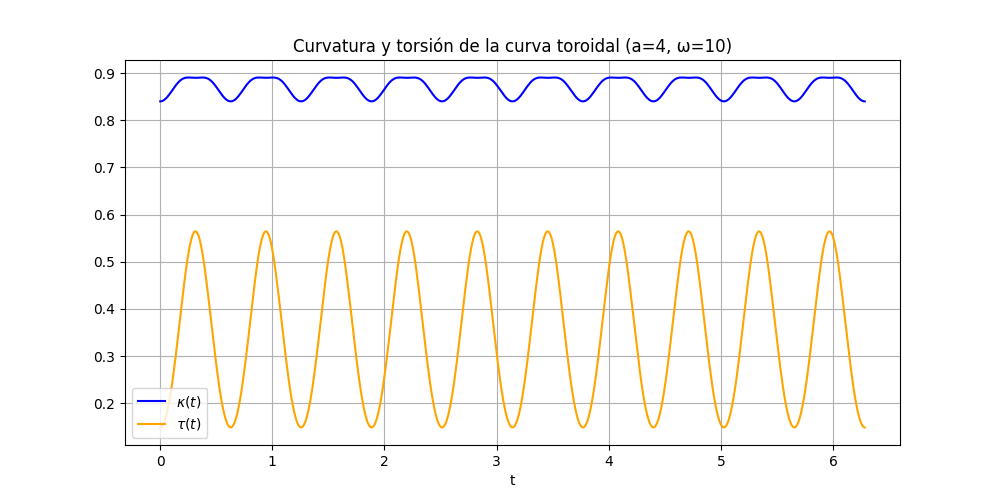

In [43]:

# Lambdify
kappa_func = sp.lambdify(t, kappa_expr, modules='numpy')
tau_func = sp.lambdify(t, tau_expr, modules='numpy')

# Dominio
t_vals = np.linspace(0, 2*np.pi, 500)
kappa_vals = kappa_func(t_vals)
tau_vals = tau_func(t_vals)

# Gráfica
plt.figure(figsize=(10,5))
plt.plot(t_vals, kappa_vals, label=r'$\kappa(t)$', color='blue')
plt.plot(t_vals, tau_vals, label=r'$\tau(t)$', color='orange')
plt.xlabel('t')
plt.title('Curvatura y torsión de la curva toroidal (a=4, ω=10)')
plt.legend()
plt.grid(True)
plt.show()

**Análisis de la curvatura y torsión de la curva toroidal**

La gráfica muestra cómo varían la curvatura $ \kappa(t) $ (en azul) y la torsión $ \tau(t) $ (en naranja) a lo largo de la curva toroidal definida por los parámetros $a = 4$ y $\omega = 10$.

Podemos observar que:

- **La curvatura $ \kappa(t) $ se mantiene casi constante**, con pequeñas oscilaciones suaves alrededor de un valor cercano a 0.88. Esto indica que la trayectoria espacial de la curva es bastante regular en cuanto a su "radio de curvatura", con giros moderados y controlados.

- **La torsión $ \tau(t) $ varía de forma periódica y pronunciada**, reflejando los cambios en el plano de osculación. Esto es característico de curvas que "retuercen" en el espacio 3D, como esta espiral que envuelve un toro.

En conjunto, esta gráfica revela que la curva tiene un **comportamiento geométrico estable en curvatura pero dinámico en torsión**, lo cual es típico en curvas helicoidales o toroidales que combinan suavidad con complejidad espacial.

**Referencia:**  
do Carmo, M. P. (1976). *Differential Geometry of Curves and Surfaces*. Prentice-Hall.  
Capítulo 1, sección 5: “Curvature and Torsion of Space Curves”.


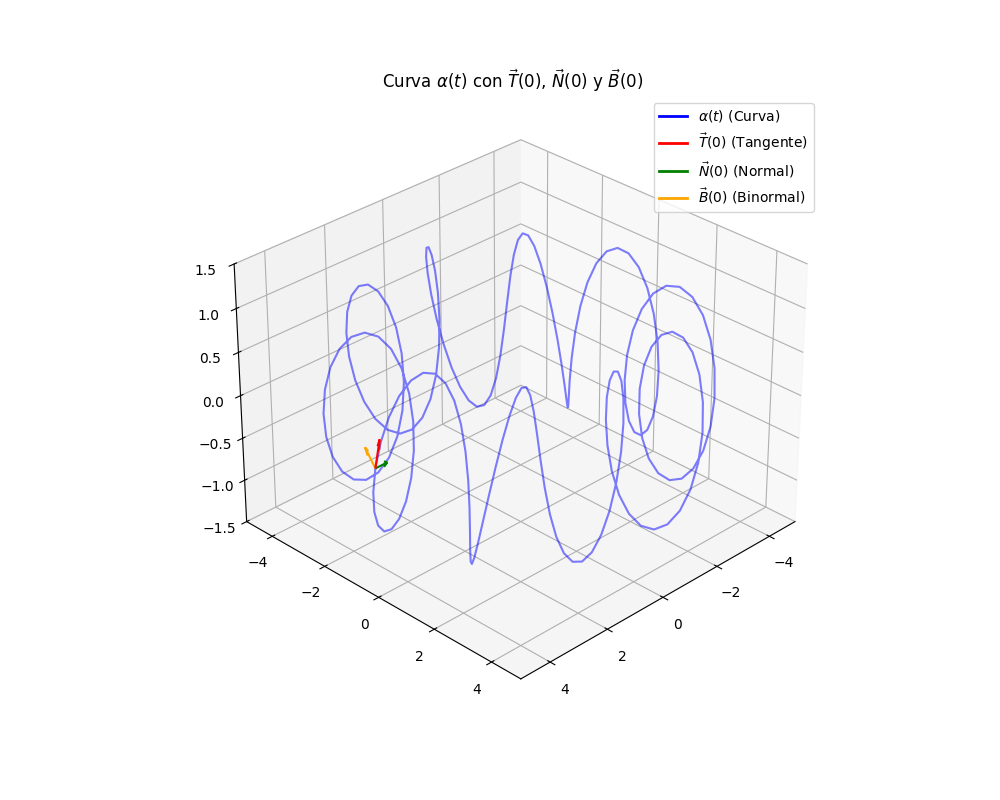

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

# === Parámetros ===
a, w = 4, 10
t_vals = np.linspace(0, 2*np.pi, 200)

def alpha_np(t):
    return np.array([
        (a + np.cos(w * t)) * np.cos(t),
        (a + np.cos(w * t)) * np.sin(t),
        np.sin(w * t)
    ])

def alpha_prime_np(t):
    return np.array([
        -w * np.sin(w*t) * np.cos(t) - (a + np.cos(w*t)) * np.sin(t),
        -w * np.sin(t) * np.cos(w*t) + (a + np.cos(w*t)) * np.cos(t),
        w * np.cos(w*t)
    ])

def alpha_double_prime_np(t):
    return np.array([
        -w**2 * np.cos(w*t) * np.cos(t) + 2 * w * np.sin(t) * np.sin(w*t) - (a + np.cos(w*t)) * np.cos(t),
        -w**2 * np.cos(w*t) * np.sin(t) - 2 * w * np.cos(t) * np.sin(w*t) - (a + np.cos(w*t)) * np.sin(t),
        -w**2 * np.sin(w*t)
    ])

def frenet_frame(t):
    r1 = alpha_prime_np(t)
    r2 = alpha_double_prime_np(t)
    T = r1 / np.linalg.norm(r1)
    N = r2 - np.dot(r2, T) * T
    N /= np.linalg.norm(N)
    B = np.cross(T, N)
    return T, N, B

# === Curva completa para mostrar ===
curve = np.array([alpha_np(t) for t in t_vals])

# === Evaluar en t = 0 ===
t0 = 0
p0 = alpha_np(t0)
T0, N0, B0 = frenet_frame(t0)
scale = 0.4

# === Graficar ===
fig2 = plt.figure(figsize=(10, 8))
ax = fig2.add_subplot(111, projection='3d')

# Curva
ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color='blue', alpha=0.5)

# Vectores en t = 0
ax.quiver(*p0, *(scale * T0), color='red')
ax.quiver(*p0, *(scale * N0), color='green')
ax.quiver(*p0, *(scale * B0), color='orange')

# Ajustes de ejes y vista
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-1.5, 1.5)
ax.view_init(elev=30, azim=45)
ax.set_title(r"Curva $\alpha(t)$ con $\vec{T}(0)$, $\vec{N}(0)$ y $\vec{B}(0)$")

# Leyenda usando Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=r'$\alpha(t)$ (Curva)'),
    Line2D([0], [0], color='red', lw=2, label=r'$\vec{T}(0)$ (Tangente)'),
    Line2D([0], [0], color='green', lw=2, label=r'$\vec{N}(0)$ (Normal)'),
    Line2D([0], [0], color='orange', lw=2, label=r'$\vec{B}(0)$ (Binormal)')
]
ax.legend(handles=legend_elements)

plt.show()


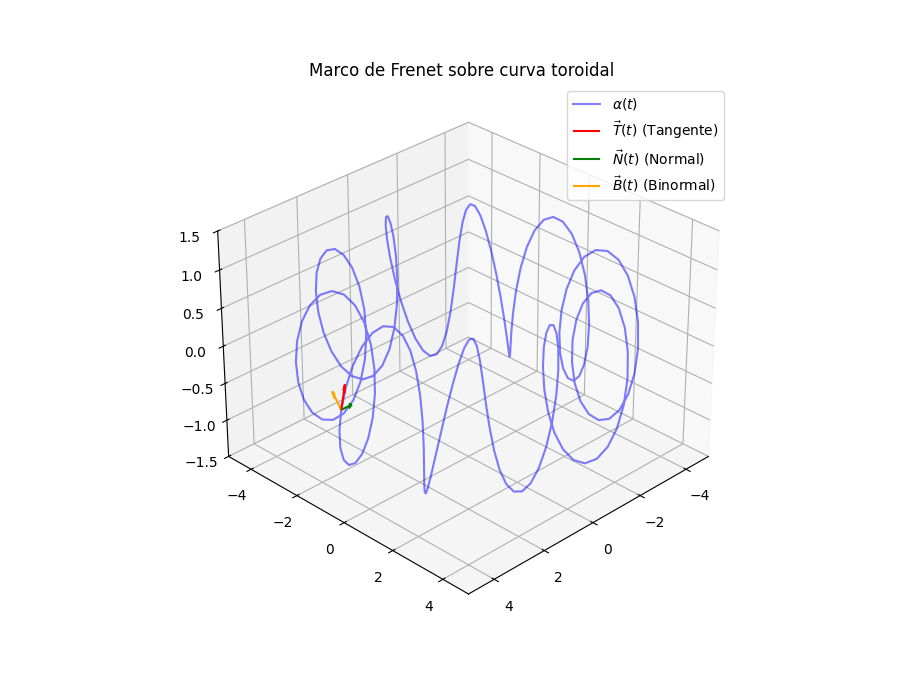

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

# === Parámetros ===
a, w = 4, 10
t_vals = np.linspace(0, 2*np.pi, 200)

def alpha_np(t):
    return np.array([
        (a + np.cos(w * t)) * np.cos(t),
        (a + np.cos(w * t)) * np.sin(t),
        np.sin(w * t)
    ])

def alpha_prime_np(t):
    return np.array([
        -w * np.sin(w*t) * np.cos(t) - (a + np.cos(w*t)) * np.sin(t),
        -w * np.sin(t) * np.cos(w*t) + (a + np.cos(w*t)) * np.cos(t),
        w * np.cos(w*t)
    ])

def alpha_double_prime_np(t):
    return np.array([
        -w**2 * np.cos(w*t) * np.cos(t) + 2 * w * np.sin(t) * np.sin(w*t) - (a + np.cos(w*t)) * np.cos(t),
        -w**2 * np.cos(w*t) * np.sin(t) - 2 * w * np.cos(t) * np.sin(w*t) - (a + np.cos(w*t)) * np.sin(t),
        -w**2 * np.sin(w*t)
    ])

def frenet_frame(t):
    r1 = alpha_prime_np(t)
    r2 = alpha_double_prime_np(t)
    T = r1 / np.linalg.norm(r1)
    N = r2 - np.dot(r2, T) * T
    N /= np.linalg.norm(N)
    B = np.cross(T, N)
    return T, N, B

# === Inicializar figura ===
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
curve = np.array([alpha_np(t) for t in t_vals])
ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color='blue', alpha=0.5, label=r'$\alpha(t)$')

# Ajustes de ejes
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-1.5, 1.5)
ax.view_init(elev=30, azim=45)
ax.set_title("Marco de Frenet sobre curva toroidal")
ax.legend()

# === Vectores a actualizar ===
T_quiver = N_quiver = B_quiver = None

def update(frame):
    global T_quiver, N_quiver, B_quiver
    t = t_vals[frame]
    p = alpha_np(t)
    T, N, B = frenet_frame(t)
    scale = 0.4

    # Eliminar vectores anteriores
    for q in [T_quiver, N_quiver, B_quiver]:
        if q:
            q.remove()

    # Agregar nuevos
    T_quiver = ax.quiver(*p, *(scale * T), color='red')
    N_quiver = ax.quiver(*p, *(scale * N), color='green')
    B_quiver = ax.quiver(*p, *(scale * B), color='orange')
    return T_quiver, N_quiver, B_quiver
ax.quiver(0, 0, 0, 0, 0, 0, color='red', label=r'$\vec{T}(t)$ (Tangente)')
ax.quiver(0, 0, 0, 0, 0, 0, color='green', label=r'$\vec{N}(t)$ (Normal)')
ax.quiver(0, 0, 0, 0, 0, 0, color='orange', label=r'$\vec{B}(t)$ (Binormal)')

ax.legend()
# === Crear animación ===
ani = FuncAnimation(fig, update, frames=len(t_vals), interval=50, blit=False)

# === Guardar como GIF ===
ani.save("frenet_animation.gif", writer=PillowWriter(fps=20))


### Aplicación destacada del marco de Frenet: navegación de vehículos autónomos

Una de las aplicaciones más relevantes del marco de Frenet se encuentra en la **planificación de trayectorias para vehículos autónomos** (como autos o drones). En este contexto:

- La curva $\alpha(t)$ representa el camino que debe seguir el vehículo.
- El vector tangente $\vec{T}(t)$ indica la **dirección de movimiento** en cada instante.
- El vector normal $\vec{N}(t)$ permite ajustar la **curvatura del giro**, clave para evitar derrapes o trayectorias abruptas.
- El vector binormal $\vec{B}(t)$ es especialmente útil en entornos tridimensionales (como en vuelo de drones), para mantener la **estabilidad rotacional** del vehículo.

Estos vectores se usan para construir **marcos de referencia móviles**, conocidos como “curvilinear coordinate frames”, que simplifican los cálculos de control, predicción de movimiento y simulación física.

---

**Referencia aplicada**:  
Werling, M., Ziegler, J., Kammel, S., & Thrun, S. (2010). *Optimal trajectory generation for dynamic street scenarios in a frenet frame*. IEEE International Conference on Robotics and Automation (ICRA).  
📎 [Enlace al paper](https://ieeexplore.ieee.org/document/5509797)
